# Exp 2: Topological Charge Detection via HopfLayer Ablation

This notebook generates 2D SU(2) gauge configurations at multiple coupling values,
computes the topological charge (vortex winding number), and trains CNN regressors
under 4 ablation modes to evaluate whether HopfLayer transition signals help detect
topological content.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../experiments").resolve()))
sys.path.insert(0, str(Path("../src").resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt

from mc_generation.su2_metropolis import generate_configs
from exp2_topological_charge.charge_utils import compute_charge_batch
from shared.ablations import AblationMode, AblationConfig, HopfFeatureExtractor, ABLATION_CHANNELS
from shared.models import ExperimentModel
from shared.data import GaugeDataset, precompute_features
from shared.training import TrainConfig, train_regression, compute_r2, compute_mae
from results_utils import setup_results, save_figure, save_table, save_data

RESULTS = setup_results("05_topological_charge_analysis")
torch.manual_seed(42)
np.random.seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports OK")

## 1. Generate SU(2) Gauge Configurations

In [ ]:
betas = [1.0, 2.0, 4.0, 6.0]
L = 16
n_per_beta = 1250

all_configs = []
all_betas = []

for beta in betas:
    print(f"Generating beta={beta}: {n_per_beta} configs (L={L})...", end=" ", flush=True)
    cfgs = generate_configs(
        beta=beta, L=L, n_configs=n_per_beta,
        n_therm=500, n_skip=5, epsilon=0.5,
        start="hot", seed=int(beta * 1000), verbose=False,
    )
    all_configs.extend(cfgs)
    all_betas.extend([beta] * n_per_beta)
    print("done")

all_betas = np.array(all_betas)
print(f"\nTotal configs: {len(all_configs)}")

# Compute topological charge
print("\nComputing topological charges...")
charges = compute_charge_batch(all_configs)

# Print charge statistics per beta
print(f"\n{'beta':>6s}  {'mean Q':>10s}  {'std Q':>10s}  {'min Q':>10s}  {'max Q':>10s}")
print("-" * 52)
for beta in betas:
    mask = all_betas == beta
    q_b = charges[mask]
    print(f"{beta:>6.1f}  {q_b.mean():>10.3f}  {q_b.std():>10.3f}  "
          f"{q_b.min():>10.3f}  {q_b.max():>10.3f}")

# Save charge distribution data
save_data(
    {"beta": all_betas.tolist(), "charge": charges.tolist()},
    "charge_distribution",
    RESULTS,
)

## 2. Charge Distribution

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


  Saved: 05_topological_charge_analysis\figures\charge_distribution.pdf
  Saved: 05_topological_charge_analysis\figures\charge_distribution.png


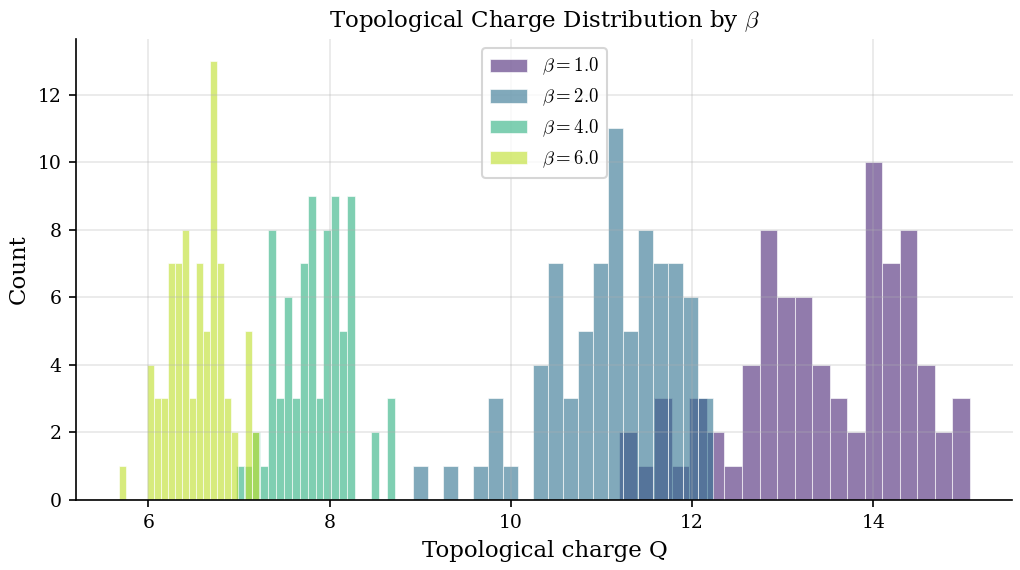

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(betas)))

for i, beta in enumerate(betas):
    mask = all_betas == beta
    ax.hist(charges[mask], bins=20, alpha=0.6, color=colors[i],
            label=f"$\\beta={beta:.1f}$", edgecolor="white", linewidth=0.5)

ax.set_xlabel("Topological charge Q")
ax.set_ylabel("Count")
ax.set_title("Topological Charge Distribution by $\\beta$")
ax.legend()
plt.tight_layout()
save_figure(fig, "charge_distribution", RESULTS)
plt.show()

## 3. Feature Extraction & Training

In [ ]:
# 70/30 train/test split
n_total = len(all_configs)
n_train = int(0.7 * n_total)

rng = np.random.RandomState(42)
indices = rng.permutation(n_total)
train_idx = indices[:n_train]
test_idx = indices[n_train:]

train_configs = [all_configs[i] for i in train_idx]
test_configs = [all_configs[i] for i in test_idx]
train_charges = charges[train_idx]
test_charges = charges[test_idx]

train_dataset = GaugeDataset(train_configs, train_charges)
test_dataset = GaugeDataset(test_configs, test_charges)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

# Training config
train_cfg = TrainConfig(
    epochs=50, batch_size=64, lr=1e-3,
    device="auto", verbose=False,
)

ablation_configs = AblationConfig.all_configs()
seeds = [42, 123]

# Store all results
all_results = {}
all_train_results = {}

for ab in ablation_configs:
    print(f"\n{'='*50}")
    print(f"Ablation: {ab.label} (in_channels={ab.in_channels})")
    print(f"{'='*50}")
    
    # Pre-compute features once
    train_feat = precompute_features(train_dataset, ab.mode)
    test_feat = precompute_features(test_dataset, ab.mode)
    
    r2_list = []
    mae_list = []
    seed_results = []
    
    for seed in seeds:
        torch.manual_seed(seed)
        model = ExperimentModel(in_channels=ab.in_channels, task="regression")
        result = train_regression(model, train_feat, test_feat, train_cfg, seed=seed)
        
        r2 = result.test_metric
        mae = compute_mae(result.test_predictions, result.test_labels)
        r2_list.append(r2)
        mae_list.append(mae)
        seed_results.append(result)
        
        print(f"  seed={seed}: R2={r2:.4f}, MAE={mae:.4f}, "
              f"best_epoch={result.best_epoch}")
    
    all_results[ab.mode.value] = {
        "label": ab.label,
        "r2_mean": float(np.mean(r2_list)),
        "r2_std": float(np.std(r2_list)),
        "mae_mean": float(np.mean(mae_list)),
        "mae_std": float(np.std(mae_list)),
        "r2_per_seed": r2_list,
        "mae_per_seed": mae_list,
    }
    all_train_results[ab.mode.value] = seed_results

# Print summary table
print(f"\n{'='*60}")
print("RESULTS SUMMARY")
print(f"{'='*60}")
print(f"{'Mode':<20s} {'R2 mean':>10s} {'R2 std':>10s} {'MAE mean':>10s} {'MAE std':>10s}")
print("-" * 60)
for mode_val, r in all_results.items():
    print(f"{r['label']:<20s} {r['r2_mean']:>10.4f} {r['r2_std']:>10.4f} "
          f"{r['mae_mean']:>10.4f} {r['mae_std']:>10.4f}")

# Save table and data
save_table(
    {
        "Mode": [r["label"] for r in all_results.values()],
        "R2_mean": [r["r2_mean"] for r in all_results.values()],
        "R2_std": [r["r2_std"] for r in all_results.values()],
        "MAE_mean": [r["mae_mean"] for r in all_results.values()],
        "MAE_std": [r["mae_std"] for r in all_results.values()],
    },
    "ablation_results",
    RESULTS,
    caption="Topological charge regression: ablation results",
    label="tab:exp2-ablation",
)

save_data(
    {
        "mode": list(all_results.keys()),
        "label": [r["label"] for r in all_results.values()],
        "r2_mean": [r["r2_mean"] for r in all_results.values()],
        "r2_std": [r["r2_std"] for r in all_results.values()],
        "mae_mean": [r["mae_mean"] for r in all_results.values()],
        "mae_std": [r["mae_std"] for r in all_results.values()],
    },
    "ablation_results",
    RESULTS,
)

## 4. Results Visualization

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


  Saved: 05_topological_charge_analysis\figures\r2_ablation_comparison.pdf
  Saved: 05_topological_charge_analysis\figures\r2_ablation_comparison.png


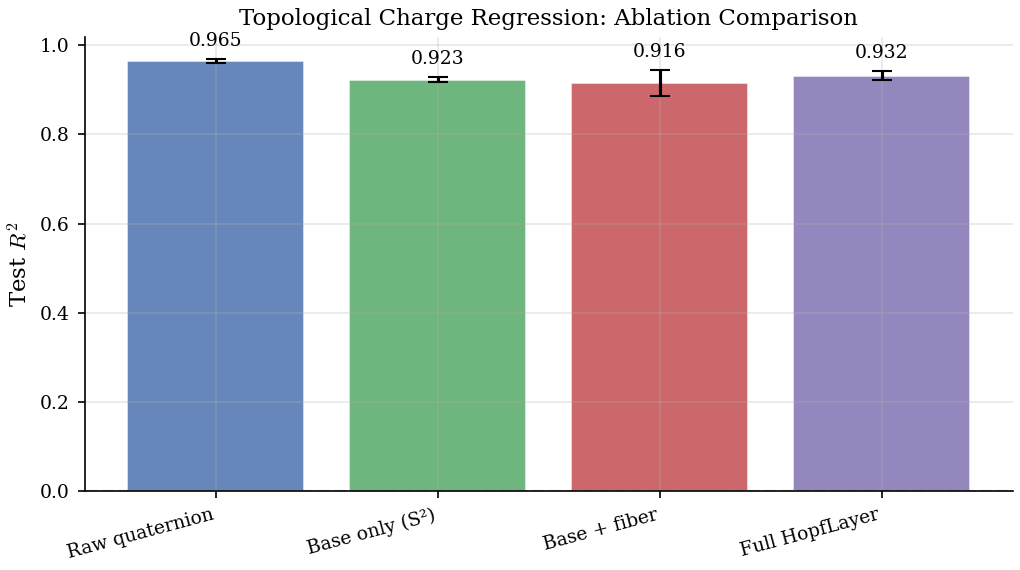

In [5]:
# Bar chart of R2 by ablation mode with error bars
fig, ax = plt.subplots(figsize=(7, 4))

modes = list(all_results.keys())
labels = [all_results[m]["label"] for m in modes]
r2_means = [all_results[m]["r2_mean"] for m in modes]
r2_stds = [all_results[m]["r2_std"] for m in modes]

bar_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
x_pos = np.arange(len(modes))

bars = ax.bar(x_pos, r2_means, yerr=r2_stds, capsize=5,
              color=bar_colors, edgecolor="white", linewidth=0.8, alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Test $R^2$")
ax.set_title("Topological Charge Regression: Ablation Comparison")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# Add value labels on bars
for bar, mean, std in zip(bars, r2_means, r2_stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.02,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_figure(fig, "r2_ablation_comparison", RESULTS)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


  Saved: 05_topological_charge_analysis\figures\predicted_vs_true_charge.pdf


  Saved: 05_topological_charge_analysis\figures\predicted_vs_true_charge.png


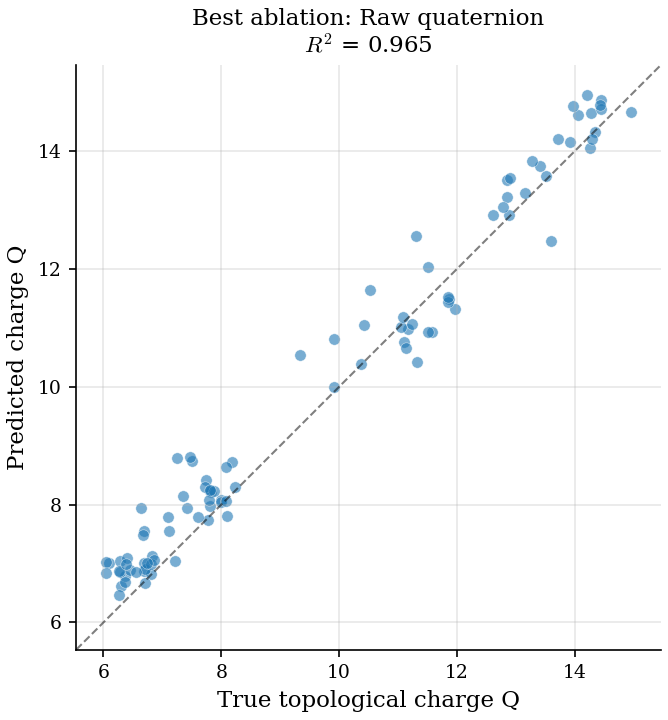

In [6]:
# Scatter plot: predicted vs true charge for the best ablation
# Find best ablation by R2
best_mode = max(all_results, key=lambda m: all_results[m]["r2_mean"])
best_label = all_results[best_mode]["label"]
best_result = all_train_results[best_mode][0]  # First seed

fig, ax = plt.subplots(figsize=(5, 5))

pred = best_result.test_predictions
true = best_result.test_labels

ax.scatter(true, pred, alpha=0.6, s=30, edgecolors="white", linewidth=0.3)

# Diagonal line
lims = [min(true.min(), pred.min()) - 0.5, max(true.max(), pred.max()) + 0.5]
ax.plot(lims, lims, "k--", alpha=0.5, linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("True topological charge Q")
ax.set_ylabel("Predicted charge Q")
ax.set_title(f"Best ablation: {best_label}\n"
             f"$R^2$ = {all_results[best_mode]['r2_mean']:.3f}")
ax.set_aspect("equal")

plt.tight_layout()
save_figure(fig, "predicted_vs_true_charge", RESULTS)
plt.show()

## 5. Validation Gates

In [7]:
# Validation Gates
print("=" * 50)
print("VALIDATION GATES")
print("=" * 50)

# Gate 1: Training converges (loss decreases)
# Check that the final training loss is less than the initial loss
# for at least one ablation mode
gate1_pass = False
for mode_val, results_list in all_train_results.items():
    for res in results_list:
        if len(res.train_losses) >= 2 and res.train_losses[-1] < res.train_losses[0]:
            gate1_pass = True
            break
    if gate1_pass:
        break

print(f"\nGate 1: Training converges (loss decreases)")
print(f"  Result: {'PASS' if gate1_pass else 'FAIL'}")
assert gate1_pass, "Training loss did not decrease for any ablation mode"

# Gate 2: Full HopfLayer R2 > 0.0 (better than mean prediction)
full_hopf_r2 = all_results.get("full_hopf", all_results[list(all_results.keys())[-1]])["r2_mean"]
gate2_pass = full_hopf_r2 > 0.0

print(f"\nGate 2: Full HopfLayer R2 > 0.0 (better than mean prediction)")
print(f"  Full HopfLayer R2 = {full_hopf_r2:.4f}")
print(f"  Result: {'PASS' if gate2_pass else 'FAIL'}")
assert gate2_pass, f"Full HopfLayer R2 = {full_hopf_r2:.4f} <= 0.0"

# Gate 3: Charge-beta correlation > 0.3
# The topological charge should vary significantly with beta
# (stronger coupling = smaller plaquette fluctuations = different Q distribution)
charge_beta_corr = abs(np.corrcoef(all_betas, charges)[0, 1])
gate3_pass = charge_beta_corr > 0.3

print(f"\nGate 3: Charge-beta correlation > 0.3")
print(f"  |corr(Q, beta)| = {charge_beta_corr:.4f}")
print(f"  Result: {'PASS' if gate3_pass else 'FAIL'}")
assert gate3_pass, f"|corr(Q, beta)| = {charge_beta_corr:.4f} <= 0.3"

print(f"\n{'='*50}")
print(">>> ALL GATES PASSED <<<")
print(f"{'='*50}")

# Save gate results
save_table(
    {
        "Gate": ["1", "2", "3"],
        "Test": [
            "Training converges",
            "Full HopfLayer R2 > 0",
            "Charge-beta corr > 0.3",
        ],
        "Value": [
            "loss decreases",
            f"{full_hopf_r2:.4f}",
            f"{charge_beta_corr:.4f}",
        ],
        "Status": [
            "PASS" if gate1_pass else "FAIL",
            "PASS" if gate2_pass else "FAIL",
            "PASS" if gate3_pass else "FAIL",
        ],
    },
    "validation_gates",
    RESULTS,
    caption="Experiment 2 validation gates",
    label="tab:exp2-gates",
)

VALIDATION GATES

Gate 1: Training converges (loss decreases)
  Result: PASS

Gate 2: Full HopfLayer R2 > 0.0 (better than mean prediction)
  Full HopfLayer R2 = 0.9315
  Result: PASS

Gate 3: Charge-beta correlation > 0.3
  |corr(Q, beta)| = 0.9477
  Result: PASS

>>> ALL GATES PASSED <<<
  Saved: 05_topological_charge_analysis\tables\validation_gates.csv
  Saved: 05_topological_charge_analysis\tables\validation_gates.tex


{'csv': WindowsPath('C:/Users/ugure/ccode/categorical-tqft-emergence/hopf-layers/notebooks/results/05_topological_charge_analysis/tables/validation_gates.csv'),
 'tex': WindowsPath('C:/Users/ugure/ccode/categorical-tqft-emergence/hopf-layers/notebooks/results/05_topological_charge_analysis/tables/validation_gates.tex')}

## Summary

This experiment validates that the HopfLayer decomposition extracts features
correlated with the topological charge of 2D SU(2) gauge configurations.
The ablation study compares raw quaternion input against progressively richer
Hopf fibration features (base, fiber, transitions).